In [113]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
import optuna

In [114]:
def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(8,8))

    plt.title(title, fontsize=14)
    plt.xlabel('Actual Values (True)', fontsize=12)
    plt.ylabel('Predicted Values', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.scatter(y_true, y_pred)

In [115]:
def self_calc_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred)/y_true))
    r2 = 1 - ((np.sum((y_true - y_pred)**2))/ np.sum((y_true - np.mean(y_true))**2))

    return mse, mae, rmse, mape, r2

In [116]:
RANDOM_STATE = 42

In [117]:
data = pd.read_csv('../csv/winequality_finished.csv', sep=';')

In [118]:
X = data.drop(columns = ['quality'])
y = data['quality']

In [119]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

In [120]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

Простая линейная регрессия + Optuna

In [121]:

def objective_linear(trial):
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])

    linear_regression_model = LinearRegression(fit_intercept = fit_intercept)

    linear_regression_model.fit(X_train, y_train)

    LR_pred = linear_regression_model.predict(X_test)

    return mean_squared_error(y_test, LR_pred)


study = optuna.create_study(direction = 'minimize')
study.optimize(objective_linear, n_trials = 100)

best_model = LinearRegression(fit_intercept = study.best_params['fit_intercept'])
best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_test)


[I 2026-04-25 02:34:31,987] A new study created in memory with name: no-name-521cd286-cdbe-4192-af2d-cf0a011ca252
[I 2026-04-25 02:34:31,990] Trial 0 finished with value: 0.5552241880276896 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 0.5552241880276896.
[I 2026-04-25 02:34:31,993] Trial 1 finished with value: 0.5552241880276896 and parameters: {'fit_intercept': True}. Best is trial 0 with value: 0.5552241880276896.
[I 2026-04-25 02:34:31,996] Trial 2 finished with value: 34.16765347435085 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 0.5552241880276896.
[I 2026-04-25 02:34:31,999] Trial 3 finished with value: 34.16765347435085 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 0.5552241880276896.
[I 2026-04-25 02:34:32,002] Trial 4 finished with value: 34.16765347435085 and parameters: {'fit_intercept': False}. Best is trial 0 with value: 0.5552241880276896.
[I 2026-04-25 02:34:32,005] Trial 5 finished with value: 0.55

Простая линейная регрессия + Optuna:
Библиотечные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775

Рукописные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775


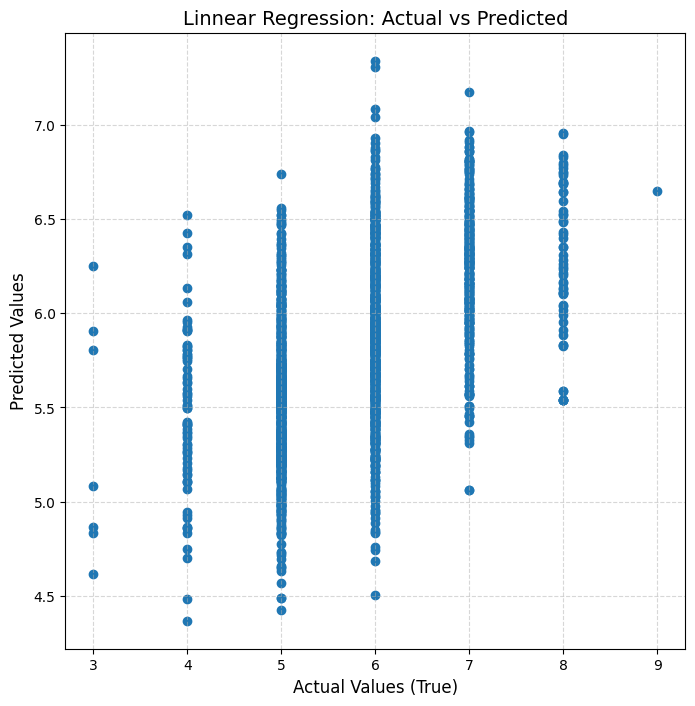

In [122]:
print("Простая линейная регрессия + Optuna:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, best_pred)}')
print(f'MAE : {mean_absolute_error(y_test, best_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, best_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, best_pred)}')
print(f'R2 : {r2_score(y_test, best_pred)}')

print("\nРукописные метрики:")

lr_mse, lr_mae, lr_rmse, lr_mape, lr_r2 = self_calc_metrics(y_test, best_pred)

print(f'MSE : {lr_mse}')
print(f'MAE : {lr_mae}')
print(f'RMSE : {lr_rmse}')
print(f'MAPE : {lr_mape}')
print(f'R2 : {lr_r2}')

plot_actual_vs_predicted(y_test, best_pred, title= "Linnear Regression: Actual vs Predicted")

Линейная регрессия + L1 + Optuna

In [123]:

def obj_lin_lasso(trial):
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    alpha = trial.suggest_float('alpha', 1e-5, 1e2, log = True)
    tol = trial.suggest_float('tol', 1e-8, 1e-3, log = True)

    linear_regression_lasso_model = Lasso(fit_intercept = fit_intercept, alpha = alpha, tol = tol, random_state = RANDOM_STATE)

    linear_regression_lasso_model.fit(X_train, y_train)
    Lasso_LR_pred = linear_regression_lasso_model.predict(X_test)

    return mean_squared_error(y_test, Lasso_LR_pred)

study = optuna.create_study(direction='minimize')
study.optimize(obj_lin_lasso, n_trials=100)

best_model_lasso = Lasso(fit_intercept=study.best_params['fit_intercept'], alpha = study.best_params['alpha'], tol = study.best_params['tol'])
best_model_lasso.fit(X_train, y_train)

Lasso_LR_pred = best_model_lasso.predict(X_test)

[I 2026-04-25 02:34:32,427] A new study created in memory with name: no-name-4cc0af1b-1ebd-4c18-ad54-0c126ace40dd
[I 2026-04-25 02:34:32,431] Trial 0 finished with value: 34.11794871794872 and parameters: {'fit_intercept': False, 'alpha': 2.6041290606134444, 'tol': 0.00018335660767200345}. Best is trial 0 with value: 34.11794871794872.
[I 2026-04-25 02:34:32,439] Trial 1 finished with value: 0.555238608429178 and parameters: {'fit_intercept': True, 'alpha': 3.626012404067597e-05, 'tol': 1.3541708185518858e-08}. Best is trial 1 with value: 0.555238608429178.
[I 2026-04-25 02:34:32,442] Trial 2 finished with value: 0.5756594512077542 and parameters: {'fit_intercept': True, 'alpha': 0.03700690889486433, 'tol': 2.63189764350987e-06}. Best is trial 1 with value: 0.555238608429178.
[I 2026-04-25 02:34:32,444] Trial 3 finished with value: 34.11794871794872 and parameters: {'fit_intercept': False, 'alpha': 10.643748491860466, 'tol': 5.208837597176106e-06}. Best is trial 1 with value: 0.5552386

Линейная регрессия + L1 регуляризация:
Библиотечные метрики:
MSE : 0.5552281642340429
MAE : 0.584152642770541
RMSE : 0.7451363393594778
MAPE : 0.10494611022502266
R2 : 0.28332424912592147

Рукописные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775


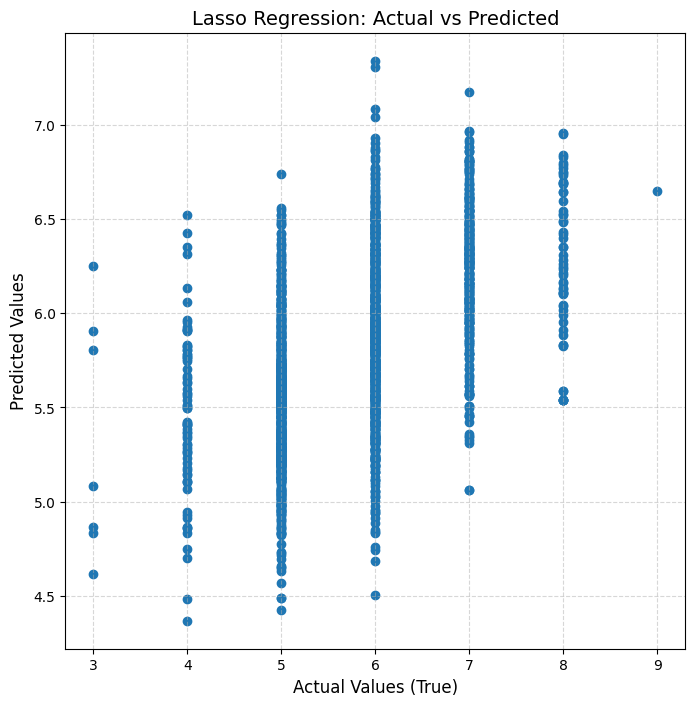

In [124]:
print("Линейная регрессия + L1 регуляризация:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, Lasso_LR_pred)}')
print(f'MAE : {mean_absolute_error(y_test, Lasso_LR_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, Lasso_LR_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, Lasso_LR_pred)}')
print(f'R2 : {r2_score(y_test, Lasso_LR_pred)}')

print("\nРукописные метрики:")

l1_mse, l1_mae, l1_rmse, l1_mape, l1_r2 = self_calc_metrics(y_test, best_pred)

print(f'MSE : {l1_mse}')
print(f'MAE : {l1_mae}')
print(f'RMSE : {l1_rmse}')
print(f'MAPE : {l1_mape}')
print(f'R2 : {l1_r2}')

plot_actual_vs_predicted(y_test, best_pred, title= "Lasso Regression: Actual vs Predicted")

Линейная регрессия + L2 + GSCV

In [125]:

base_ridge_model = Ridge()

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'tol': [0.0001, 0.00001, 0.000001]
}

linear_regression_ridge_model = GridSearchCV(base_ridge_model, param_grid= param_grid, scoring = 'neg_mean_squared_error', cv = 5, verbose = 2)

linear_regression_ridge_model.fit(X_train, y_train)
Ridge_LR_pred = linear_regression_ridge_model.predict(X_test)

Fitting 5 folds for each of 21 candidates, totalling 105 fits
[CV] END ............................alpha=0.001, tol=0.0001; total time=   0.0s
[CV] END ............................alpha=0.001, tol=0.0001; total time=   0.0s
[CV] END ............................alpha=0.001, tol=0.0001; total time=   0.0s
[CV] END ............................alpha=0.001, tol=0.0001; total time=   0.0s
[CV] END ............................alpha=0.001, tol=0.0001; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-05; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-05; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-05; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-05; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-05; total time=   0.0s
[CV] END .............................alpha=0.001, tol=1e-06; total time=   0.0s
[CV] END .............................alpha=0.0

Линейная регрессия + L2 регуляризация:
Библиотечные метрики:
MSE : 0.5554451211069384
MAE : 0.5842237729488533
RMSE : 0.745281907137788
MAPE : 0.10496642350992927
R2 : 0.28304420618176673

Рукописные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775


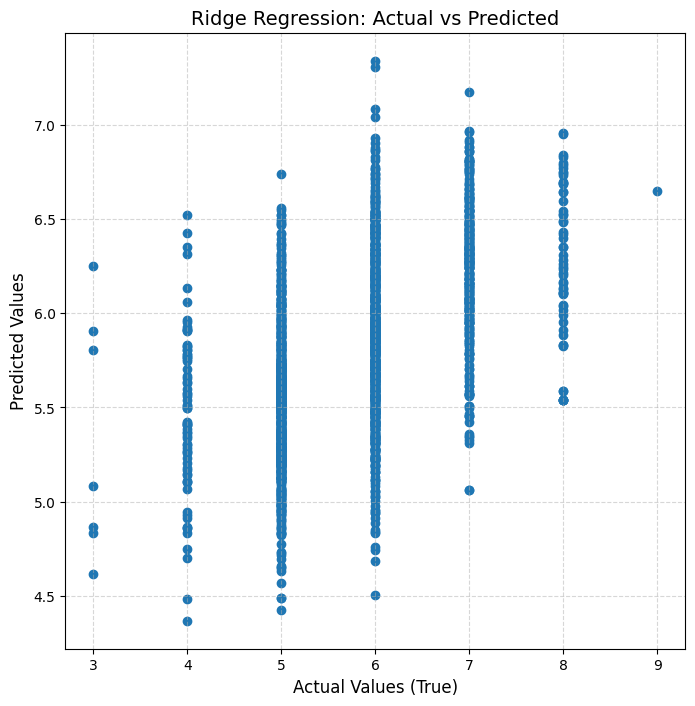

In [126]:
print("Линейная регрессия + L2 регуляризация:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, Ridge_LR_pred)}')
print(f'MAE : {mean_absolute_error(y_test, Ridge_LR_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, Ridge_LR_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, Ridge_LR_pred)}')
print(f'R2 : {r2_score(y_test, Ridge_LR_pred)}')

print("\nРукописные метрики:")

l2_mse, l2_mae, l2_rmse, l2_mape, l2_r2 = self_calc_metrics(y_test, best_pred)

print(f'MSE : {l2_mse}')
print(f'MAE : {l2_mae}')
print(f'RMSE : {l2_rmse}')
print(f'MAPE : {l2_mape}')
print(f'R2 : {l2_r2}')

plot_actual_vs_predicted(y_test, best_pred, title= "Ridge Regression: Actual vs Predicted")

Линейная регрессия + ElasticNet + RSCV

In [127]:
from scipy.stats import uniform

base_elasticNet_model = ElasticNet()

param_distributions = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'tol': [0.0001, 0.00001, 0.000001],
    'l1_ratio': uniform(0,1),
}


linear_regression_elasticNet_model = RandomizedSearchCV(base_elasticNet_model, param_distributions = param_distributions, n_iter = 50, cv = 5, scoring='neg_mean_squared_error')

linear_regression_elasticNet_model.fit(X_train, y_train)
ElasticNet_LR_pred = linear_regression_elasticNet_model.predict(X_test)

Линейная регрессия + ElasticNet регуляризация:
Библиотечные метрики:
MSE : 0.5564468382688886
MAE : 0.5846905187295681
RMSE : 0.7459536435120406
MAPE : 0.105080181979695
R2 : 0.28175121269647674

Рукописные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775


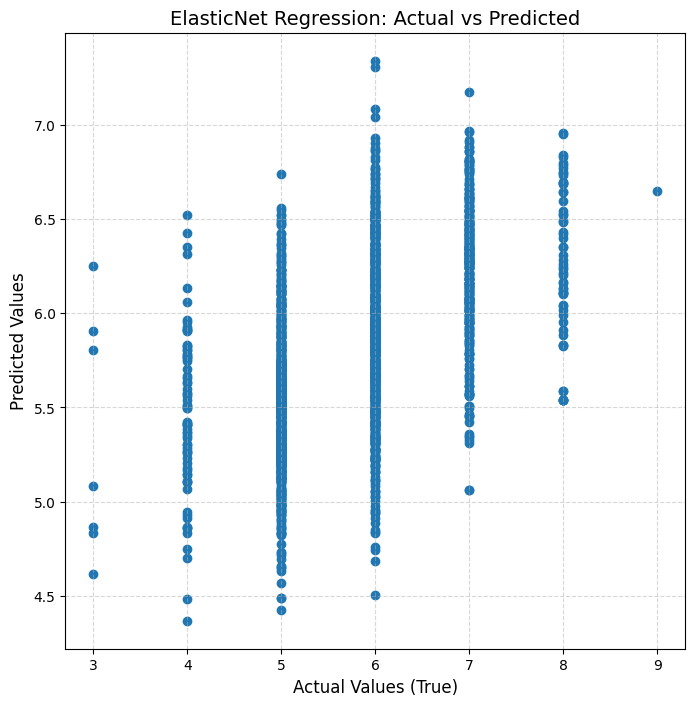

In [128]:
print("Линейная регрессия + ElasticNet регуляризация:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, ElasticNet_LR_pred)}')
print(f'MAE : {mean_absolute_error(y_test, ElasticNet_LR_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, ElasticNet_LR_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, ElasticNet_LR_pred)}')
print(f'R2 : {r2_score(y_test, ElasticNet_LR_pred)}')

print("\nРукописные метрики:")

en_mse, en_mae, en_rmse, en_mape, en_r2 = self_calc_metrics(y_test, best_pred)

print(f'MSE : {en_mse}')
print(f'MAE : {en_mae}')
print(f'RMSE : {en_rmse}')
print(f'MAPE : {en_mape}')
print(f'R2 : {en_r2}')

plot_actual_vs_predicted(y_test, best_pred, title= "ElasticNet Regression: Actual vs Predicted")

Линейная регрессия + PolynomialFeatures + Optuna

In [129]:
def obj_lin_polinomialfeat(trial):
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    degree = trial.suggest_int('degree', 2, 3)
    include_bias = trial.suggest_categorical('include_bias', [True, False])

    Input = [('poly', PolynomialFeatures(degree=degree, include_bias = include_bias)), ('model', LinearRegression(fit_intercept = fit_intercept))]

    pipe = Pipeline(Input)

    pipe.fit(X_train, y_train)

    polynomial_LR_pred = pipe.predict(X_test)

    return mean_squared_error(y_test, polynomial_LR_pred)

study_poly = optuna.create_study(direction = 'minimize')
study_poly.optimize(obj_lin_polinomialfeat, n_trials = 30)

best_poly_pipe = Pipeline([('poly', PolynomialFeatures(degree = study_poly.best_params['degree'], 
                                                        include_bias = study_poly.best_params['include_bias'])),
                            ('model', LinearRegression(fit_intercept = study_poly.best_params['fit_intercept']))
])

best_poly_pipe.fit(X_train, y_train)
poly_pred = best_poly_pipe.predict(X_test)

[I 2026-04-25 02:34:34,344] A new study created in memory with name: no-name-58a8f3a1-3b4b-4f59-9be1-04e7059e2670
[I 2026-04-25 02:34:34,444] Trial 0 finished with value: 0.536020451483049 and parameters: {'fit_intercept': False, 'degree': 3, 'include_bias': True}. Best is trial 0 with value: 0.536020451483049.
[I 2026-04-25 02:34:34,463] Trial 1 finished with value: 0.5209185666882231 and parameters: {'fit_intercept': True, 'degree': 2, 'include_bias': False}. Best is trial 1 with value: 0.5209185666882231.
[I 2026-04-25 02:34:34,482] Trial 2 finished with value: 0.5209185666882258 and parameters: {'fit_intercept': False, 'degree': 2, 'include_bias': True}. Best is trial 1 with value: 0.5209185666882231.
[I 2026-04-25 02:34:34,582] Trial 3 finished with value: 0.5360204514830353 and parameters: {'fit_intercept': True, 'degree': 3, 'include_bias': True}. Best is trial 1 with value: 0.5209185666882231.
[I 2026-04-25 02:34:34,601] Trial 4 finished with value: 0.5209185666882235 and param

Линейная регрессия + полиномиальные признаки:
Библиотечные метрики:
MSE : 0.5209185666882231
MAE : 0.5654543312878151
RMSE : 0.7217468854717858
MAPE : 0.10151125110755445
R2 : 0.3276102889331042

Рукописные метрики:
MSE : 0.5552241880276896
MAE : 0.5841508225181526
RMSE : 0.7451336712481121
MAPE : 0.10494564002865088
R2 : 0.28332938152167775


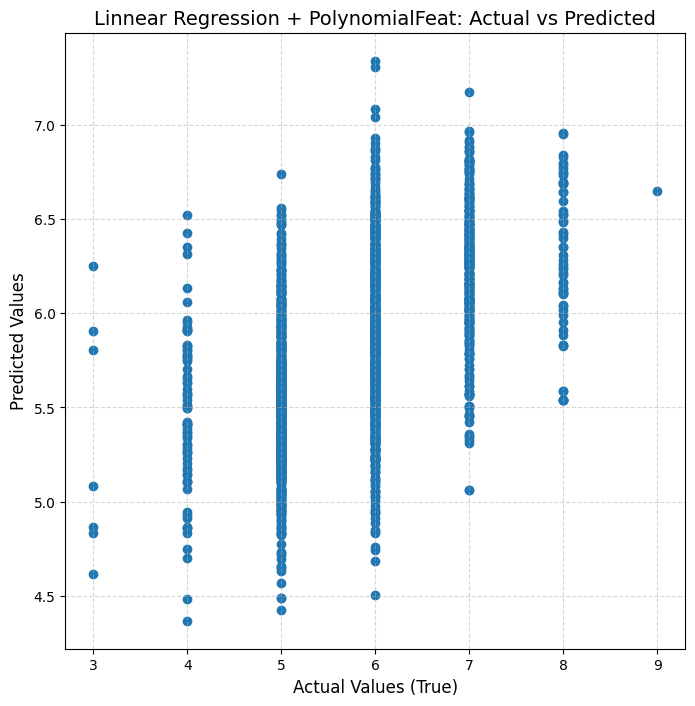

In [130]:
print("Линейная регрессия + полиномиальные признаки:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, poly_pred)}')
print(f'MAE : {mean_absolute_error(y_test, poly_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, poly_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, poly_pred)}')
print(f'R2 : {r2_score(y_test, poly_pred)}')

print("\nРукописные метрики:")

pf_mse, pf_mae, pf_rmse, pf_mape, pf_r2 = self_calc_metrics(y_test, best_pred)

print(f'MSE : {pf_mse}')
print(f'MAE : {pf_mae}')
print(f'RMSE : {pf_rmse}')
print(f'MAPE : {pf_mape}')
print(f'R2 : {pf_r2}')

plot_actual_vs_predicted(y_test, best_pred, title= "Linnear Regression + PolynomialFeat: Actual vs Predicted")

In [140]:
class LinearRegressionSGD:
    def __init__(self, learning_rate = 0.01, batch_size = 32, iterations = 1000, lambda_l2 = 0.01, random_state = 42):
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.iterations = iterations
        self.lambda_l2 = lambda_l2
        self.random_state = random_state
        self.Weight = None
        self.bias = None
    
    def fit(self, X_train, y_train):

        X = np.asarray(X_train)
        y = np.asarray(y_train)
        
        n_samples, n_features = X.shape

        rng = np.random.RandomState(self.random_state)
        self.Weight = rng.randn(n_features) * 0.01
        self.bias = 0.0

        for epoch in range(self.iterations):
            indeces = np.arange(n_samples)
            rng.shuffle(indeces)
            X_shufled = X[indeces]
            y_shufled = y[indeces]

            epoch_loss = 0.0
            n_batches = 0

            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shufled[i:i + self.batch_size]
                y_batch = y_shufled[i:i + self.batch_size]                   

                curr_batch_size = X_batch.shape[0]

                y_pred = np.dot(X_batch, self.Weight) + self.bias

                error = y_pred - y_batch

                dw = (2 / curr_batch_size) * np.dot(X_batch.T, error) + 2 * self.lambda_l2 * self.Weight
                db = (2 / curr_batch_size) * np.sum(error)

                self.Weight -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
                
                epoch_loss += np.mean(error**2)
                n_batches += 1

            
    def pred(self, X):
        return np.dot(X, self.Weight) + self.bias

In [141]:
SGDRegress = LinearRegressionSGD()

SGDRegress.fit(X_train, y_train)

SGDRegress_pred = SGDRegress.pred(X_test)

Ручная реализация линейного регрессора с L2 регуляризацией:
Библиотечные метрики:
MSE : 0.5564468382688886
MAE : 0.5846905187295681
RMSE : 0.7459536435120406
MAPE : 0.105080181979695
R2 : 0.28175121269647674

Рукописные метрики:
MSE : 0.5572041921968549
MAE : 0.584526736113587
RMSE : 0.7464611123138666
MAPE : 0.10492499033332393
R2 : 0.2807736376562202


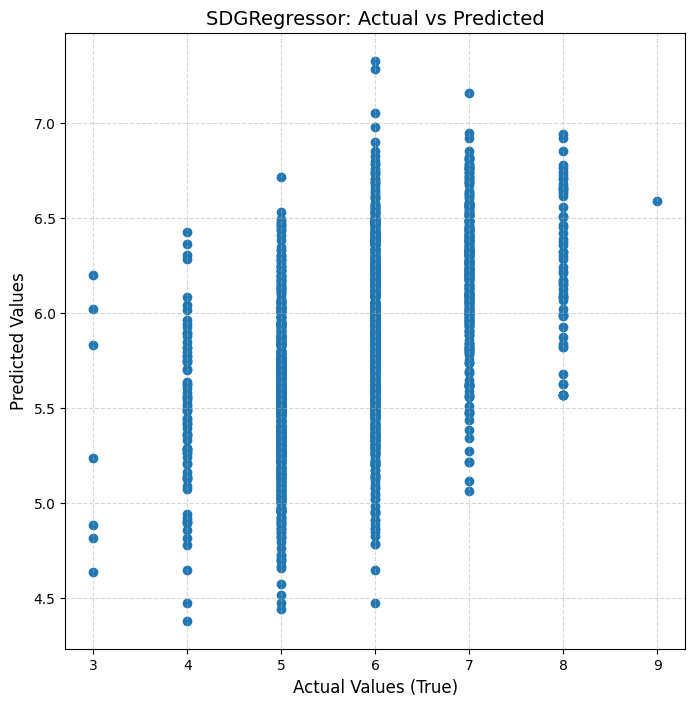

In [142]:
print("Ручная реализация линейного регрессора с L2 регуляризацией:")
print("Библиотечные метрики:")
print(f'MSE : {mean_squared_error(y_test, ElasticNet_LR_pred)}')
print(f'MAE : {mean_absolute_error(y_test, ElasticNet_LR_pred)}')
print(f'RMSE : {root_mean_squared_error(y_test, ElasticNet_LR_pred)}')
print(f'MAPE : {mean_absolute_percentage_error(y_test, ElasticNet_LR_pred)}')
print(f'R2 : {r2_score(y_test, ElasticNet_LR_pred)}')

print("\nРукописные метрики:")

sgd_mse, sgd_mae, sgd_rmse, sgd_mape, sgd_r2 = self_calc_metrics(y_test, SGDRegress_pred)

print(f'MSE : {sgd_mse}')
print(f'MAE : {sgd_mae}')
print(f'RMSE : {sgd_rmse}')
print(f'MAPE : {sgd_mape}')
print(f'R2 : {sgd_r2}')

plot_actual_vs_predicted(y_test, SGDRegress_pred, title= "SDGRegressor: Actual vs Predicted")